# Choosing the study region: Assam vs Kamrup vs Guwahati vs the IITG corridor

**Granica × IIT Guwahati Hackathon · Team Granica LATENT**

**Question:** which geographic scope best fits (a) our data and analysis, (b) our own measurements (CE 323 lab studies near IITG), (c) the public datasets we can join, and (d) a real problem that IITG students live with?

**Candidate regions:**

| id | region | definition |
|---|---|---|
| R0 | **Assam** | all 44,114 accidents |
| R1 | **Kamrup + Guwahati City** | police districts KAMRUP and GUWAHATI CITY (≈ Kamrup rural + Kamrup Metro) |
| R2 | **Guwahati City** | police district GUWAHATI CITY (Guwahati Police Commissionerate) |
| R3 | **IITG corridor (20 km)** | accidents within 20 km of IIT Guwahati: North Guwahati, Amingaon/Changsari, Saraighat bridge, Jalukbari, the city core, Dispur, Khanapara |
| R4 | **IITG core (10 km)** | within 10 km: campus, north bank, Saraighat, Jalukbari/Maligaon, west city |

**Anchors** (external data we want to join): IIT Guwahati (lab studies), the Saraighat bridge NH-27/31 (Maurya et al. speed/headway study), GMCH (Level-II trauma centre), and LGBI airport VEGT (METAR visibility).

In [1]:
import os, json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
DATA = os.environ.get('IRAD_DIR', '../iRAD_output'); OUT = os.environ.get('EDA_OUT', 'eda_outputs'); os.makedirs(f'{OUT}/figs', exist_ok=True)
load = lambda n: pd.read_parquet(f'{DATA}/iRAD_Assam_all__{n}.parquet')
A, V, D, P, PE, RD = load('Accidents'), load('Vehicles'), load('Drivers'), load('Passengers'), load('Pedestrians'), load('Road_Details')
BLUE, ORANGE, AQUA, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#8c8b85'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': '#e6e5e0', 'grid.linewidth': .6, 'axes.axisbelow': True, 'axes.titlesize': 11,
                     'axes.titleweight': 'bold', 'font.size': 9})
def save(fig, name): fig.tight_layout(); fig.savefig(f'{OUT}/figs/{name}.png', bbox_inches='tight'); plt.show()
pct = lambda x: round(100 * float(x), 1)

ANCHORS = {'IIT Guwahati': (26.1878, 91.6916), 'Saraighat bridge (Maurya site)': (26.1790, 91.6815),
           'GMCH (Level-II trauma)': (26.1560, 91.7670), 'LGBI airport VEGT': (26.1061, 91.5859)}
def km(lat, lon, ref):
    p = np.radians; a = np.sin(p(lat - ref[0]) / 2) ** 2 + np.cos(p(ref[0])) * np.cos(p(lat)) * np.sin(p(lon - ref[1]) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))
A['d_iitg'] = km(A.latitude, A.longitude, ANCHORS['IIT Guwahati'])
A['d_gmch'] = km(A.latitude, A.longitude, ANCHORS['GMCH (Level-II trauma)'])
A['d_vegt'] = km(A.latitude, A.longitude, ANCHORS['LGBI airport VEGT'])
dist = A.district_name.str.upper().str.strip()
REG = {'R0 Assam': A.index == A.index,
       'R1 Kamrup+Guwahati City': dist.isin(['KAMRUP', 'GUWAHATI CITY']),
       'R2 Guwahati City': dist.eq('GUWAHATI CITY'),
       'R3 IITG corridor 20 km': A.d_iitg <= 20,
       'R4 IITG core 10 km': A.d_iitg <= 10}
print({k: int(v.sum()) for k, v in REG.items()})

{'R0 Assam': 44114, 'R1 Kamrup+Guwahati City': 8690, 'R2 Guwahati City': 5487, 'R3 IITG corridor 20 km': 6170, 'R4 IITG core 10 km': 3316}


## 1. Derived per-accident features used for comparison

In [2]:
vt = V.vehicle_type
A['has_2w'] = A.accident_id.isin(V.loc[vt == 'Two Wheeler', 'accident_id'])
A['has_truck'] = A.accident_id.isin(V.loc[vt.isin(['Truck/Lorry', 'Heavy Articulated Vehicle/Trolley']), 'accident_id'])
A['has_ped'] = A.accident_id.isin(PE.accident_id) | A.collision_type.fillna('').str.contains('Pedestrian')
A['n_veh'] = A.accident_id.map(V.groupby('accident_id').size()).fillna(0)
A['dark'] = A.light_condition.fillna('').str.contains('Night|Darkness')
A['fog'] = A.weather_condition.fillna('').str.contains('Fog')
A['nh'] = A.road_classification.eq('National Highway')
A['urban'] = A.local_body.fillna('').str.contains('Municipal|Municipality|Town')
A['full_form'] = A.sections_present.fillna('').str.contains('Transport Details')
A['skeletal'] = ~A.sections_present.fillna('').str.contains('Vehicle Details')
A['fatal'] = A.severity.eq('Fatal')
A['unwitnessed'] = (A.n_veh == 1) & A.dark & A.local_body.eq('Gram Panchayat')
A['has_road_details'] = A.accident_id.isin(RD.accident_id)
cols = ['severity', 'mode_of_hospitalization', 'hours_accident_to_death']
persons = pd.concat([D[['accident_id'] + cols], P[['accident_id'] + cols], PE[['accident_id'] + cols]], ignore_index=True)

## 2. Region scorecard

In [3]:
def region_stats(mask):
    a = A[mask]; ids = set(a.accident_id); ps = persons[persons.accident_id.isin(ids)]
    ksi = ps[ps.severity.isin(['Fatal', 'Grievous Injury'])]
    dth = ps.hours_accident_to_death.dropna(); dth = dth[(dth >= 0) & (dth <= 720)]
    return pd.Series({
        'accidents': len(a), 'fatal accidents': int(a.fatal.sum()), 'persons killed': int(a.killed_total.sum()),
        'accidents / year (2023-25)': round(a.accident_year.between(2023, 2025).sum() / 3),
        'full form (with inspection) %': pct(a.full_form.mean()), 'skeletal form %': pct(a.skeletal.mean()),
        'road details section %': pct(a.has_road_details.mean()),
        'collision nature usable %': pct(a.collision_nature.notna().mean()),
        'fatal %': pct(a.fatal.mean()), 'involves 2W %': pct(a.has_2w.mean()), 'involves truck %': pct(a.has_truck.mean()),
        'involves pedestrian %': pct(a.has_ped.mean()), 'night/dark %': pct(a.dark.mean()), 'fog %': pct(a.fog.mean()),
        'national highway %': pct(a.nh.mean()), 'urban local body %': pct(a.urban.mean()),
        'unwitnessed proxy %': pct(a.unwitnessed.mean()),
        'KSI via 108 ambulance %': pct(ksi.mode_of_hospitalization.eq('108 Ambulance').mean()),
        'KSI via private vehicle %': pct(ksi.mode_of_hospitalization.eq('Private Vehicle').mean()),
        'deaths with time-to-death': int(len(dth)), 'median hours to death': round(float(dth.median()), 2) if len(dth) else np.nan,
        'median km to GMCH': round(float(a.d_gmch.median()), 1), 'median km to VEGT (METAR)': round(float(a.d_vegt.median()), 1),
        'median km to IITG': round(float(a.d_iitg.median()), 1), 'police stations': a.station_name.nunique(),
    })
SC = pd.DataFrame({k: region_stats(v) for k, v in REG.items()})
display(SC); SC.to_csv(f'{OUT}/region_scorecard.csv')

,R0 Assam,R1 Kamrup+Guwahati City,R2 Guwahati City,R3 IITG corridor 20 km,R4 IITG core 10 km
accidents,44114.0,8690.00,5487.00,6170.00,3316.00
fatal accidents,10740.0,1983.00,1032.00,1233.00,611.00
persons killed,11711.0,2128.00,1100.00,1313.00,650.00
accidents / year (2023-25),12366.0,2358.00,1476.00,1679.00,897.00
full form (with inspection) %,47.1,58.80,70.10,60.70,61.20
skeletal form %,15.5,11.90,5.90,10.30,10.30
road details section %,13.0,25.60,38.00,28.50,30.60
collision nature usable %,84.5,87.90,91.70,87.80,87.80
fatal %,24.3,22.80,18.80,20.00,18.40
involves 2W %,45.7,47.00,46.20,47.70,49.30


## 3. Is the local picture representative of Assam?

Compare the distributions of crash modes, vehicle types, light and road class between each region and Assam using the **total variation distance** (TVD: 0 = identical, 1 = disjoint). A low TVD means local findings can borrow statewide priors. A high TVD means the region behaves differently and needs its own parameters.

In [4]:
def tvd(a, b):
    pa, pb = a.value_counts(normalize=True), b.value_counts(normalize=True)
    idx = pa.index.union(pb.index); return round(0.5 * (pa.reindex(idx, fill_value=0) - pb.reindex(idx, fill_value=0)).abs().sum(), 3)
vtype_first = V.groupby('accident_id').vehicle_type.apply(lambda s: '+'.join(sorted(set(s.dropna().astype(str)))))
A['vehicle_mix'] = A.accident_id.map(vtype_first).fillna('none')
feat = ['collision_nature', 'collision_type', 'vehicle_mix', 'light_condition', 'road_classification', 'severity']
TV = pd.DataFrame({k: {f: tvd(A.loc[m, f].fillna('NA'), A[f].fillna('NA')) for f in feat} for k, m in REG.items() if k != 'R0 Assam'})
display(TV); TV.to_csv(f'{OUT}/region_tvd_vs_assam.csv')

,R1 Kamrup+Guwahati City,R2 Guwahati City,R3 IITG corridor 20 km,R4 IITG core 10 km
collision_nature,0.126,0.182,0.138,0.144
collision_type,0.093,0.147,0.105,0.109
vehicle_mix,0.093,0.160,0.115,0.123
light_condition,0.079,0.130,0.106,0.077
road_classification,0.101,0.222,0.191,0.259
severity,0.059,0.139,0.073,0.076


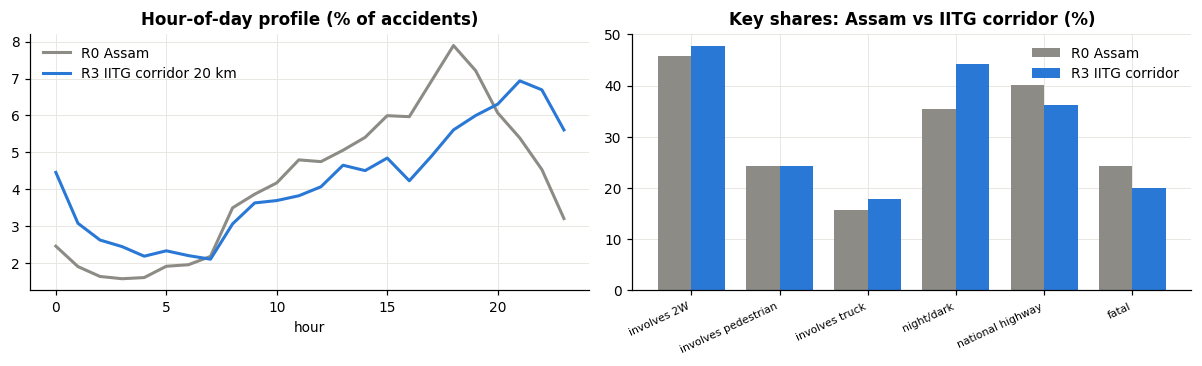

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
for k, c in [('R0 Assam', GREY), ('R3 IITG corridor 20 km', BLUE)]:
    h = A[REG[k]].groupby('accident_hour').size(); axs[0].plot(h.index, h / h.sum() * 100, color=c, lw=2, label=k)
axs[0].set_title('Hour-of-day profile (% of accidents)'); axs[0].legend(frameon=False); axs[0].set_xlabel('hour')
keys = ['involves 2W %', 'involves pedestrian %', 'involves truck %', 'night/dark %', 'national highway %', 'fatal %']
x = np.arange(len(keys)); w = .38
axs[1].bar(x - w / 2, SC.loc[keys, 'R0 Assam'], w, color=GREY, label='R0 Assam')
axs[1].bar(x + w / 2, SC.loc[keys, 'R3 IITG corridor 20 km'], w, color=BLUE, label='R3 IITG corridor')
axs[1].set_xticks(x); axs[1].set_xticklabels([k.replace(' %', '') for k in keys], rotation=25, ha='right', fontsize=7)
axs[1].set_title('Key shares: Assam vs IITG corridor (%)'); axs[1].legend(frameon=False)
save(fig, 'R1_assam_vs_corridor')

## 4. The IITG corridor on a map

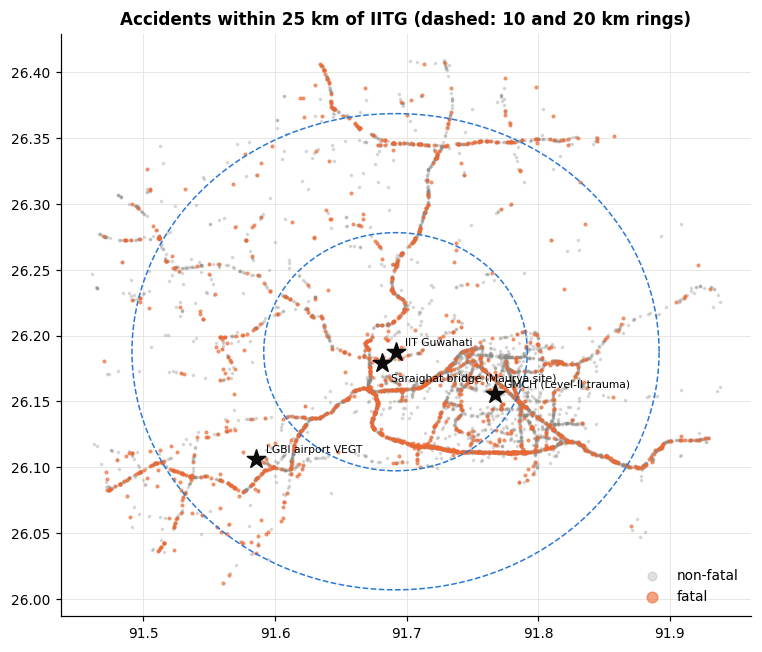

In [6]:
m = A.d_iitg <= 25
g = A[m]
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(g.longitude[~g.fatal], g.latitude[~g.fatal], s=2, alpha=.25, color=GREY, label='non-fatal')
ax.scatter(g.longitude[g.fatal], g.latitude[g.fatal], s=3, alpha=.6, color=ORANGE, label='fatal')
for r in [10, 20]:
    t = np.linspace(0, 2 * np.pi, 200); lat0, lon0 = ANCHORS['IIT Guwahati']
    ax.plot(lon0 + (r / 111.32) / np.cos(np.radians(lat0)) * np.cos(t), lat0 + (r / 110.57) * np.sin(t), color=BLUE, lw=1, ls='--')
for name, (la, lo) in ANCHORS.items():
    ax.scatter(lo, la, marker='*', s=160, color='#0b0b0b', zorder=5); ax.annotate(name, (lo, la), xytext=(6, -12) if 'Saraighat' in name else (6, 4), textcoords='offset points', fontsize=7)
ax.set_title('Accidents within 25 km of IITG (dashed: 10 and 20 km rings)'); ax.set_aspect('equal'); ax.legend(frameon=False, markerscale=4, loc='lower right')
save(fig, 'R2_corridor_map')

In [7]:
st = A[REG['R3 IITG corridor 20 km']].groupby(['district_name', 'station_name']).agg(
    n=('accident_id', 'size'), fatal=('fatal', 'sum'), median_km_iitg=('d_iitg', 'median')).sort_values('n', ascending=False)
display(st.head(25)); st.to_csv(f'{OUT}/corridor_police_stations.csv')
off = A[REG['R3 IITG corridor 20 km'] & ~dist.isin(['KAMRUP', 'GUWAHATI CITY'])]
print('corridor points filed by stations of other districts (likely geotag errors):', len(off), f'({pct(len(off) / REG["R3 IITG corridor 20 km"].sum())}%)')

n  fatal  median_km_iitg
district_name station_name                                   
GUWAHATI CITY DISPUR P.S           661     84       11.217452
              JALUKBARI OP         552     96        4.400697
              BASISTHA             491    140       12.653440
KAMRUP        CHANGSARI PS         480     85        7.360817
GUWAHATI CITY GARCHUK PS           429    139        8.584571
              AZARA                418     87       11.787405
              JALUKBARI            321     50        3.366572
KAMRUP        HAJO POLICE STATION  262     54       14.077994
GUWAHATI CITY PALTAN BAZAR         222     31        6.537156
              NOONMATI             203     39       12.121821
              FATASIL AMBARI       193     40        6.406550
KAMRUP        BAIHATA CHARIALI     187     54       18.172935
              PALASHBARI           181     72       18.235396
GUWAHATI CITY CHANDMARI            154     10        8.396864
              BHARALUMUKH          153     25        4.260779
KAMRUP        NORTH GUWAHATI       151     42        2.275551
              KAMALPUR             150     46       17.617296
GUWAHATI CITY JORABAT OP           144     24       18.309649
              GEETA NAGAR          130      5        8.902933
              PAN BAZAR            124     14        5.199338
              KHANAPARA OP         111     16       15.760009
KAMRUP        SUALKUCHI             91     30       12.596584
GUWAHATI CITY BHANGAGARH PS         84      6        8.355170
              HATIGAON PS           79     14       11.369385
              LATASIL               60      7        6.490840

corridor points filed by stations of other districts (likely geotag errors): 22 (0.4%)


In [8]:
# roads inside the corridor: text road names (to be matched to OSM later) + hotspot cells
rc = A[REG['R3 IITG corridor 20 km']]
print(rc.road_classification.value_counts(dropna=False).head(8).to_string())
cell = rc.groupby([rc.latitude.round(3), rc.longitude.round(3)]).agg(n=('accident_id', 'size'), fatal=('fatal', 'sum'),
        station=('station_name', 'first')).sort_values('n', ascending=False)
print('\n~100 m hotspot cells in the corridor with ≥5 accidents:', int((cell.n >= 5).sum()), '| accidents in them:', int(cell[cell.n >= 5].n.sum()))
display(cell.head(12)); cell.reset_index().to_csv(f'{OUT}/corridor_hotspots_100m.csv', index=False)

road_classification
National Highway       2230
Major District Road    1476
State Highway           597
NaN                     558
Other District Road     474
Local Road              427
Village Road            249
Arterial Road           106

~100 m hotspot cells in the corridor with ≥5 accidents: 270 | accidents in them: 2033


,,n,fatal,station
latitude,longitude,,,
26.142,91.676,41,7,JALUKBARI OP
26.155,91.676,25,1,JALUKBARI OP
26.150,91.785,24,5,DISPUR P.S
26.152,91.677,19,4,JALUKBARI OP
26.116,91.719,19,4,GARCHUK PS
26.162,91.772,19,2,BHANGAGARH PS
26.254,91.692,18,2,CHANGSARI PS
26.126,91.680,16,4,JALUKBARI OP
26.152,91.655,16,4,JALUKBARI OP


## 5. Data fitness for our integration (per region)

In [9]:
fit = pd.DataFrame({
 'R0 Assam': ['very high (44k)', 'partial (2 sites near IITG)', 'only Guwahati', 'only near airports', 'yes', 'low (state-wide)', 'needed for rare modes (animal, hill, fog)'],
 'R1 Kamrup+Guwahati City': ['high (8.7k)', 'good', 'good', 'good (VEGT)', 'yes', 'medium', 'mixed urban+rural'],
 'R2 Guwahati City': ['high (5.5k)', 'good', 'good', 'good (VEGT)', 'yes', 'high', 'urban-only (misses IITG north bank)'],
 'R3 IITG corridor 20 km': ['high (6.2k)', 'best (lab sites + Saraighat inside)', 'best (Saraighat NH-27/31 inside)', 'best (VEGT ≈ 10–25 km)', 'yes (GMCH inside)', 'highest (daily commute)', 'urban + NH + rural fringe'],
 'R4 IITG core 10 km': ['medium (3.3k)', 'best', 'best', 'good', 'yes', 'highest', 'too small for rare modes'],
}, index=['iRAD sample size', 'CE 323 lab data match', 'Assam speed/headway priors (Maurya)', 'METAR visibility match', 'Level-II trauma centre in region',
          'student relevance', 'road-type diversity'])
display(fit)

,R0 Assam,R1 Kamrup+Guwahati City,R2 Guwahati City,R3 IITG corridor 20 km,R4 IITG core 10 km
iRAD sample size,very high (44k),high (8.7k),high (5.5k),high (6.2k),medium (3.3k)
CE 323 lab data match,partial (2 sites near IITG),good,good,best (lab sites + Saraighat inside),best
Assam speed/headway priors (Maurya),only Guwahati,good,good,best (Saraighat NH-27/31 inside),best
METAR visibility match,only near airports,good (VEGT),good (VEGT),best (VEGT ≈ 10–25 km),good
Level-II trauma centre in region,yes,yes,yes,yes (GMCH inside),yes
student relevance,low (state-wide),medium,high,highest (daily commute),highest
road-type diversity,"needed for rare modes (animal, hill, fog)",mixed urban+rural,urban-only (misses IITG north bank),urban + NH + rural fringe,too small for rare modes


## 6. Recommendation

**Decision: use a nested scope.** Each tier is used for what it's statistically and practically best at.

| Tier | Scope | Size | Used for |
|---|---|---|---|
| **T1: Assam (R0)** | all 44,114 accidents | 11,711 killed | Crash-mode **taxonomy and class priors** for the AI. **Rare modes** (animal, hill, fog, fall while boarding). The **need/value statistics** (the "unwitnessed" proxy is 12.9% statewide vs 3.5% in the corridor, because rural crashes are where automatic alerts matter most). Representativeness checks vs MoRTH. **Primary scope for anything aimed at AV/ADAS scenarios** |
| **T2: IITG–Guwahati corridor (R3, 20 km around IITG)** | 6,170 accidents | 1,313 killed; 36 police stations | **The integration region.** OSM roads, CE 323 lab data, the Maurya Saraighat speed/headway priors, METAR VEGT visibility, GMCH trauma access, hotspots. Calibration, validation, the demo and all location-specific conclusions |
| **T3: micro-sites inside T2** | Jalukbari–Saraighat–Amingaon NH-27 approach · Dispur / GS Road urban arterial · Changsari–Baihata NH fringe | hundreds each | Matching our lab measurement sites and the Maurya site. Parameter estimation. Scenario geometry |

**Why the corridor (R3) beats the other local options:**
- **Best data quality:**
  - full forms: 60.7% vs 47.1% for Assam
  - skeletal forms: 10.3% vs 15.5%
  - Road Details present: 28.5% vs 13%
- **Enough data:** about 1,700 accidents a year and 1,233 fatal accidents, which supports splits by mode, light and road type.
- **Everything we want to join sits inside it:** IITG and the lab sites, the Saraighat NH-27/31 study site, GMCH (median 7 km away), and VEGT airport (median 18 km).
- **More diverse than Guwahati City alone (R2):** R2 is 82% urban and leaves out the IITG north bank (the Changsari and North Guwahati stations are in Kamrup district). R3 mixes urban roads (74%), national highways (36%) and a rural fringe.
- **Defined by distance, not district,** so it's immune to Assam's 2022–23 district reorganisation. Only 0.4% of corridor points were filed by stations in other districts (likely geotag errors, which we flag).
- **Student relevance:** it's the daily IITG–Guwahati commute. The single busiest ~100 m cell in Assam is at **Jalukbari** (41 accidents), the Saraighat bridge approach, 4 km from campus. Corridor hotspot cells (≥5 accidents) hold **33% of corridor accidents** (2,033 across 270 cells).

**The corridor is not a miniature Assam** (TVD vs Assam 0.07–0.19; road class differs most).
- It has **more night/dark crashes** (44% vs 36%), **more fog** (13% vs 10%) and **more truck involvement** (18% vs 16%).
- It has **fewer "unwitnessed" crashes** (3.5% vs 12.9%) and a **lower fatal share** (20% vs 24%): closer hospitals and more witnesses.

So we **train the taxonomy and priors on Assam and calibrate or validate on the corridor**, and we say so explicitly on the slides.

**By concept:**
- **Speed-Breaker or Crash? (lead):** taxonomy and value case from T1; motion calibration, the demo and validation in T2/T3.
- **Rearview Guardian:** T2/T3, since it needs speeds and headways from local traffic.
- **Adversary Engine / Scenario Bank for AV:** T1 as the primary scope, with T2 as the fully parameterised showcase.